# Lab 2 — Task 1 (MNIST CNN): перебір конфігурацій

Датасет `train.csv` / `test.csv` у цій самій теці. Перебір за зразком `lab1_task1.ipynb`: вкладені цикли та таблиця **`results_df`**.

| Фактор | Значення |
|--------|----------|
| Оптимізатори | SGD, RMSprop, Adam, Adadelta, Adagrad, Adamax, Nadam (**7**) |
| Пари ядер Conv1 / Conv2 | `(5,5)+(3,3)`, `(4,4)+(2,2)`, `(7,7)+(5,5)`, `(3,5)+(5,3)`, `(4,6)+(3,3)` (**5**) |
| Додаткові conv-блоки | **+0**, **+1** або **+2** після двох основних |
| Аугментація | **3** пресети `ImageDataGenerator` (`aug_mild` — перший) |

Повний перебір: **7 × 5 × 3 × 3 = 315** запусків (усі `SWEEP` = `True`). За замовчуванням **`SWEEP` усі `False`**: лише **Adam**, **перша пара ядер**, **+0** додаткових блоків, **`aug_mild`**. Увімкни потрібні ключі в `SWEEP`, щоб розширити сітку.

Окремо після сітки навчається **фіксована reference-CNN** (32→48 conv, Dense 256→84→10, Adam `5e-4`, `ReduceLROnPlateau`, своя аугментація); її рядок додається до **`results_df`**


In [1]:
import os

os.environ.setdefault("KERAS_BACKEND", "torch")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from keras import backend as K
from keras.utils import set_random_seed, to_categorical
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Dropout, Flatten, Dense
from keras.callbacks import EarlyStopping
from keras.optimizers import SGD, RMSprop, Adam, Adadelta, Adagrad, Adamax, Nadam
from keras.src.legacy.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

set_random_seed(42)


In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
print("train", train.shape, "test", test.shape)
display(train.head())
display(test.head())


train (42000, 785) test (28000, 784)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


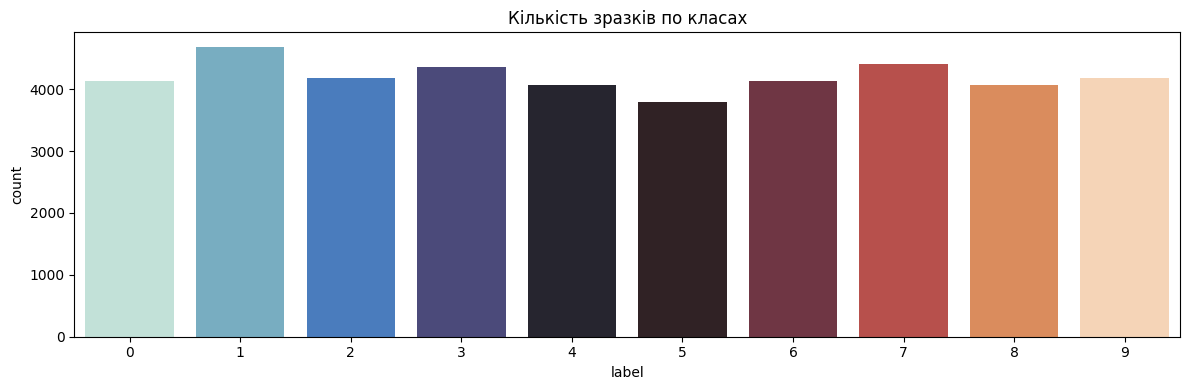

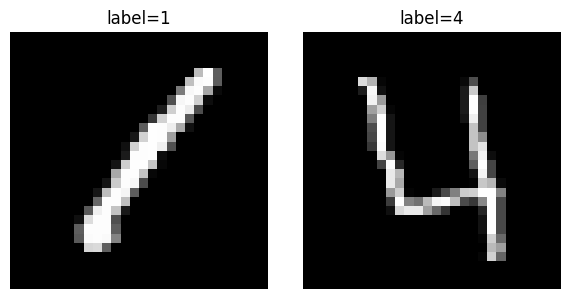

In [3]:
Y_raw = train["label"]
X_raw = train.drop(columns=["label"])

plt.figure(figsize=(12, 4))
sns.countplot(x=Y_raw, hue=Y_raw, palette="icefire", legend=False)
plt.title("Кількість зразків по класах")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
for ax, idx in zip(axes, [0, 3]):
    img = X_raw.iloc[idx].values.reshape(28, 28) / 255.0
    ax.imshow(img, cmap="gray")
    ax.set_title(f"label={Y_raw.iloc[idx]}")
    ax.axis("off")
plt.tight_layout()
plt.show()


In [4]:
X_all = (X_raw / 255.0).values.reshape(-1, 28, 28, 1).astype(np.float32)
test_X = (test / 255.0).values.reshape(-1, 28, 28, 1).astype(np.float32)

X_train, X_val, y_train_int, y_val_int = train_test_split(
    X_all,
    Y_raw.astype(int).values,
    test_size=0.1,
    random_state=42,
    stratify=Y_raw.astype(int).values,
)

Y_train = to_categorical(y_train_int, num_classes=10)
Y_val = to_categorical(y_val_int, num_classes=10)

TRAIN_SUBSAMPLE = None
rng = np.random.RandomState(42)
if TRAIN_SUBSAMPLE is not None and TRAIN_SUBSAMPLE < len(X_train):
    idx = rng.choice(len(X_train), size=TRAIN_SUBSAMPLE, replace=False)
    X_train = X_train[idx]
    Y_train = Y_train[idx]

print("X_train", X_train.shape, "X_val", X_val.shape, "test_X", test_X.shape)


X_train (37800, 28, 28, 1) X_val (4200, 28, 28, 1) test_X (28000, 28, 28, 1)


In [7]:
OPTIMIZERS = [
    ("SGD", lambda: SGD(learning_rate=0.01, momentum=0.9)),
    ("RMSprop", lambda: RMSprop()),
    ("Adam", lambda: Adam()),
    ("Adadelta", lambda: Adadelta()),
    ("Adagrad", lambda: Adagrad()),
    ("Adamax", lambda: Adamax()),
    ("Nadam", lambda: Nadam()),
]

KERNEL_PAIRS = [
    ("5x5_3x3", (5, 5), (3, 3)),
    ("4x4_2x2", (4, 4), (2, 2)),
    ("7x7_5x5", (7, 7), (5, 5)),
    ("3x5_5x3", (3, 5), (5, 3)),
    ("4x6_3x3", (4, 6), (3, 3)),
]

EXTRA_CONVS_LEVELS = [
    (0, "+0 conv-блоків"),
    (1, "+1 conv-блок"),
    (2, "+2 conv-блоки"),
]

AUG_PRESETS = [
    (
        "aug_mild",
        dict(
            featurewise_center=False,
            samplewise_center=False,
            featurewise_std_normalization=False,
            samplewise_std_normalization=False,
            zca_whitening=False,
            rotation_range=5,
            zoom_range=0.08,
            width_shift_range=0.08,
            height_shift_range=0.08,
            horizontal_flip=False,
            vertical_flip=False,
        ),
    ),
    (
        "aug_medium",
        dict(
            featurewise_center=False,
            samplewise_center=False,
            featurewise_std_normalization=False,
            samplewise_std_normalization=False,
            zca_whitening=False,
            rotation_range=15,
            zoom_range=0.15,
            width_shift_range=0.15,
            height_shift_range=0.15,
            horizontal_flip=False,
            vertical_flip=False,
        ),
    ),
    (
        "aug_strong",
        dict(
            featurewise_center=False,
            samplewise_center=False,
            featurewise_std_normalization=False,
            samplewise_std_normalization=False,
            zca_whitening=False,
            rotation_range=25,
            zoom_range=0.25,
            width_shift_range=0.25,
            height_shift_range=0.25,
            horizontal_flip=False,
            vertical_flip=False,
        ),
    ),
]

SWEEP = {
    "optimizers": False,
    "kernels": False,
    "extra_convs": False,
    "augment": False,
}

_active_opts = OPTIMIZERS if SWEEP["optimizers"] else [("Adam", lambda: Adam())]
_active_kernels = KERNEL_PAIRS if SWEEP["kernels"] else KERNEL_PAIRS[:1]
_active_extra = (
    EXTRA_CONVS_LEVELS
    if SWEEP["extra_convs"]
    else [EXTRA_CONVS_LEVELS[0]]
)
_active_aug = AUG_PRESETS if SWEEP["augment"] else [AUG_PRESETS[0]]

n_combo = len(_active_opts) * len(_active_kernels) * len(_active_extra) * len(_active_aug)
print(
    "SWEEP:",
    SWEEP,
    "| активних комбінацій:",
    n_combo,
    "(opt",
    len(_active_opts),
    "ker",
    len(_active_kernels),
    "extra",
    len(_active_extra),
    "aug",
    len(_active_aug),
    ")",
)

batch_size = 256
max_epochs = 25
early_patience = 3


def build_cnn(k1, k2, extra_convs: int) -> Sequential:
    m = Sequential()
    m.add(
        Conv2D(
            8,
            k1,
            padding="same",
            activation="relu",
            input_shape=(28, 28, 1),
        )
    )
    m.add(MaxPool2D(pool_size=(2, 2)))
    m.add(Dropout(0.25))
    m.add(Conv2D(16, k2, padding="same", activation="relu"))
    m.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))
    m.add(Dropout(0.25))
    if extra_convs >= 1:
        m.add(Conv2D(32, (3, 3), padding="same", activation="relu"))
        m.add(MaxPool2D(pool_size=(2, 2)))
        m.add(Dropout(0.25))
    if extra_convs >= 2:
        m.add(Conv2D(64, (3, 3), padding="same", activation="relu"))
        m.add(MaxPool2D(pool_size=(2, 2)))
        m.add(Dropout(0.25))
    m.add(Flatten())
    m.add(Dense(256, activation="relu"))
    m.add(Dropout(0.5))
    m.add(Dense(10, activation="softmax"))
    return m


SWEEP: {'optimizers': False, 'kernels': False, 'extra_convs': False, 'augment': False} | активних комбінацій: 1 (opt 1 ker 1 extra 1 aug 1 )


In [8]:
import json
from pathlib import Path

BEST_MODEL_PATH = Path("lab2_task1_best.keras")
BEST_HISTORY_PATH = Path("lab2_task1_best_history.json")
BEST_META_PATH = Path("lab2_task1_best_meta.json")

rows = []
steps_per_epoch = max(1, len(X_train) // batch_size)
best_val_acc_so_far = -1.0

for pair_id, k1, k2 in _active_kernels:
    for extra_convs, depth_label in _active_extra:
        for aug_name, aug_kw in _active_aug:
            datagen = ImageDataGenerator(**aug_kw)
            datagen.fit(X_train)
            flow = datagen.flow(X_train, Y_train, batch_size=batch_size, seed=42)
            for opt_name, make_opt in _active_opts:
                K.clear_session()
                model = build_cnn(k1, k2, extra_convs)
                model.compile(
                    optimizer=make_opt(),
                    loss="categorical_crossentropy",
                    metrics=["accuracy"],
                )
                es = EarlyStopping(
                    monitor="val_loss",
                    patience=early_patience,
                    restore_best_weights=True,
                )
                hist = model.fit(
                    flow,
                    epochs=max_epochs,
                    steps_per_epoch=steps_per_epoch,
                    validation_data=(X_val, Y_val),
                    callbacks=[es],
                    verbose=0,
                )
                val_acc_hist = hist.history.get("val_accuracy", [])
                val_loss_hist = hist.history.get("val_loss", [])
                val_acc_max = float(np.max(val_acc_hist)) if val_acc_hist else float("nan")
                val_loss_best = float(np.min(val_loss_hist)) if val_loss_hist else float("nan")
                row = {
                    "оптимізатор": opt_name,
                    "kernels": pair_id,
                    "k1": str(k1),
                    "k2": str(k2),
                    "extra_convs": extra_convs,
                    "глибина": depth_label,
                    "аугментація": aug_name,
                    "val_accuracy_max": val_acc_max,
                    "val_loss_min": val_loss_best,
                    "епох_навчено": len(val_loss_hist),
                }
                rows.append(row)
                if np.isfinite(val_acc_max) and val_acc_max > best_val_acc_so_far:
                    best_val_acc_so_far = val_acc_max
                    model.save(BEST_MODEL_PATH)
                    serializable = {
                        k: [float(x) for x in v] for k, v in hist.history.items()
                    }
                    with open(BEST_HISTORY_PATH, "w", encoding="utf-8") as fh:
                        json.dump(serializable, fh, ensure_ascii=False, indent=2)
                    with open(BEST_META_PATH, "w", encoding="utf-8") as fh:
                        json.dump(row, fh, ensure_ascii=False, indent=2)

results_df = pd.DataFrame(rows)
results_df


/home/ivan/Projects/nuralnetworks/.venv/lib/python3.14/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/ivan/Projects/nuralnetworks/.venv/lib/python3.14/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


,оптимізатор,kernels,k1,k2,extra_convs,глибина,аугментація,val_accuracy_max,val_loss_min,епох_навчено
0,Adam,5x5_3x3,"(5, 5)","(3, 3)",0,+0 conv-блоків,aug_mild,0.986905,0.046777,25


In [10]:
import json
from pathlib import Path

from keras.callbacks import ReduceLROnPlateau

BEST_MODEL_PATH = Path("lab2_task1_best.keras")
BEST_HISTORY_PATH = Path("lab2_task1_best_history.json")
BEST_META_PATH = Path("lab2_task1_best_meta.json")


def build_ref_cnn() -> Sequential:
    m = Sequential()
    m.add(
        Conv2D(
            32,
            (5, 5),
            padding="same",
            activation="relu",
            input_shape=(28, 28, 1),
        )
    )
    m.add(MaxPool2D(pool_size=(2, 2), strides=2))
    m.add(Conv2D(48, (5, 5), padding="valid", activation="relu"))
    m.add(MaxPool2D(pool_size=(2, 2), strides=2))
    m.add(Flatten())
    m.add(Dense(256, activation="relu"))
    m.add(Dense(84, activation="relu"))
    m.add(Dense(10, activation="softmax"))
    return m


K.clear_session()
ref_model = build_ref_cnn()
ref_model.summary()

ref_bs = 100
ref_epochs = 30
ref_adam = Adam(learning_rate=5e-4)
ref_model.compile(
    loss="categorical_crossentropy",
    metrics=["accuracy"],
    optimizer=ref_adam,
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    patience=3,
    verbose=1,
    factor=0.2,
    min_lr=1e-6,
)

ref_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
)
ref_datagen.fit(X_train)
ref_flow = ref_datagen.flow(X_train, Y_train, batch_size=ref_bs, seed=42)
ref_steps = max(1, len(X_train) // ref_bs)

hist_ref = ref_model.fit(
    ref_flow,
    steps_per_epoch=ref_steps,
    epochs=ref_epochs,
    validation_data=(X_val, Y_val),
    callbacks=[reduce_lr],
    verbose=1,
)

val_acc_hist = hist_ref.history.get("val_accuracy", [])
val_loss_hist = hist_ref.history.get("val_loss", [])
ref_val_acc_max = float(np.max(val_acc_hist)) if val_acc_hist else float("nan")
ref_val_loss_min = float(np.min(val_loss_hist)) if val_loss_hist else float("nan")

ref_row = {
    "оптимізатор": "Adam_5e-4 (фікс. CNN)",
    "kernels": "ref_32→48, conv5x5",
    "k1": "(5,5) same",
    "k2": "(5,5) valid",
    "extra_convs": -1,
    "глибина": "фіксована мережа (поза перебором)",
    "аугментація": "rot10_shift01_zoom01",
    "val_accuracy_max": ref_val_acc_max,
    "val_loss_min": ref_val_loss_min,
    "епох_навчено": len(val_loss_hist),
}

grid_best = float(results_df["val_accuracy_max"].max())
results_df = pd.concat([results_df, pd.DataFrame([ref_row])], ignore_index=True)

if np.isfinite(ref_val_acc_max) and ref_val_acc_max > grid_best:
    ref_model.save(BEST_MODEL_PATH)
    serializable = {
        k: [float(x) for x in v] for k, v in hist_ref.history.items()
    }
    with open(BEST_HISTORY_PATH, "w", encoding="utf-8") as fh:
        json.dump(serializable, fh, ensure_ascii=False, indent=2)
    with open(BEST_META_PATH, "w", encoding="utf-8") as fh:
        json.dump(ref_row, fh, ensure_ascii=False, indent=2)
    print(
        "Фіксована модель покращила найкращий результат перебору — оновлено",
        BEST_MODEL_PATH,
    )
else:
    print(
        "Фіксована модель: val_accuracy_max =",
        ref_val_acc_max,
        "| максимум по перебору =",
        grid_best,
        "— збережена найкраща з перебору не змінена.",
    )

results_df


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 48)     │        38,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       307,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        21,588 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 369,174 (1.41 MB)

 Trainable params: 369,174 (1.41 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
378/378 ━━━━━━━━━━━━━━━━━━━━ 21s 56ms/step - accuracy: 0.8547 - loss: 0.4656 - val_accuracy: 0.9712 - val_loss: 0.0940 - learning_rate: 5.0000e-04
Epoch 2/30
378/378 ━━━━━━━━━━━━━━━━━━━━ 23s 61ms/step - accuracy: 0.9571 - loss: 0.1380 - val_accuracy: 0.9798 - val_loss: 0.0743 - learning_rate: 5.0000e-04
Epoch 3/30
378/378 ━━━━━━━━━━━━━━━━━━━━ 22s 59ms/step - accuracy: 0.9693 - loss: 0.1023 - val_accuracy: 0.9800 - val_loss: 0.0648 - learning_rate: 5.0000e-04
Epoch 4/30
378/378 ━━━━━━━━━━━━━━━━━━━━ 25s 65ms/step - accuracy: 0.9756 - loss: 0.0793 - val_accuracy: 0.9876 - val_loss: 0.0423 - learning_rate: 5.0000e-04
Epoch 5/30
378/378 ━━━━━━━━━━━━━━━━━━━━ 24s 64ms/step - accuracy: 0.9774 - loss: 0.0702 - val_accuracy: 0.9867 - val_loss: 0.0419 - learning_rate: 5.0000e-04
Epoch 6/30
378/378 ━━━━━━━━━━━━━━━━━━━━ 25s 65ms/step - accuracy: 0.9825 - loss: 0.0574 - val_accuracy: 0.9850 - val_loss: 0.0460 - learning_rate: 5.0000e-04
Epoch 7/30
378/378 ━━━━━━━━━━━━━━━━━━━━ 27s 71ms/ste

,оптимізатор,kernels,k1,k2,extra_convs,глибина,аугментація,val_accuracy_max,val_loss_min,епох_навчено
0,Adam,5x5_3x3,"(5, 5)","(3, 3)",0,+0 conv-блоків,aug_mild,0.986905,0.046777,25
1,Adam_5e-4 (фікс. CNN),"ref_32→48, conv5x5","(5,5) same","(5,5) valid",-1,фіксована мережа (поза перебором),rot10_shift01_zoom01,0.995238,0.018029,30


,оптимізатор,kernels,k1,k2,extra_convs,глибина,аугментація,val_accuracy_max,val_loss_min,епох_навчено
1,Adam_5e-4 (фікс. CNN),"ref_32→48, conv5x5","(5,5) same","(5,5) valid",-1,фіксована мережа (поза перебором),rot10_shift01_zoom01,0.995238,0.018029,30
0,Adam,5x5_3x3,"(5, 5)","(3, 3)",0,+0 conv-блоків,aug_mild,0.986905,0.046777,25


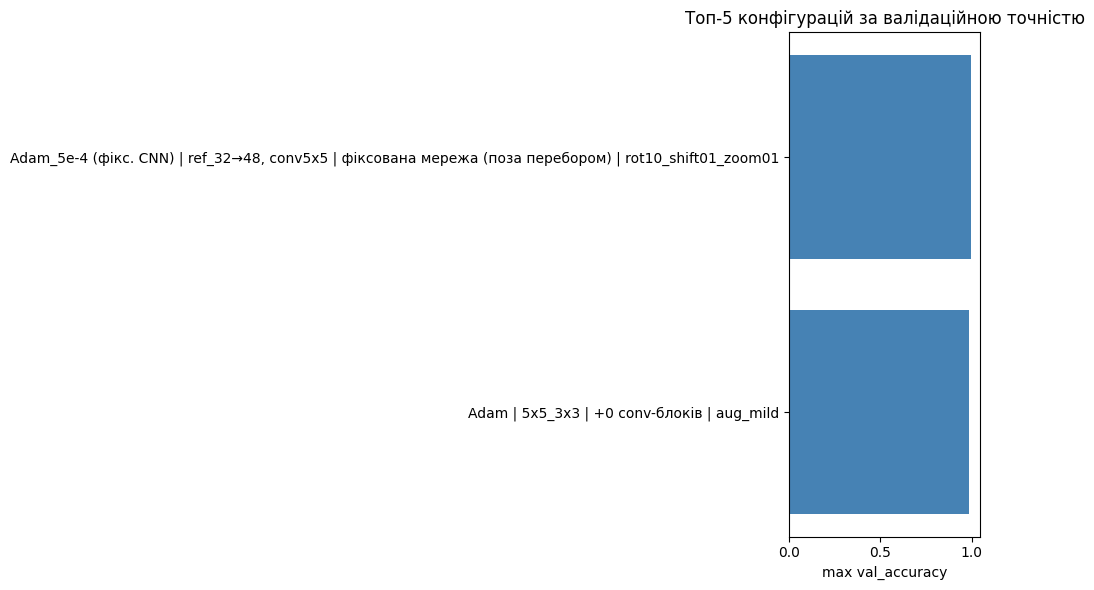

In [11]:
top = results_df.sort_values("val_accuracy_max", ascending=False).head(5)
display(top)

labels = (
    top.iloc[::-1]["оптимізатор"].astype(str)
    + " | "
    + top.iloc[::-1]["kernels"].astype(str)
    + " | "
    + top.iloc[::-1]["глибина"].astype(str)
    + " | "
    + top.iloc[::-1]["аугментація"].astype(str)
)
plt.figure(figsize=(10, 6))
plt.barh(labels, top.iloc[::-1]["val_accuracy_max"], color="steelblue")
plt.xlabel("max val_accuracy")
plt.title("Топ-5 конфігурацій за валідаційною точністю")
plt.tight_layout()
plt.show()


Топ-1 за таблицею results_df:
оптимізатор                     Adam_5e-4 (фікс. CNN)
kernels                            ref_32→48, conv5x5
k1                                         (5,5) same
k2                                        (5,5) valid
extra_convs                                        -1
глибина             фіксована мережа (поза перебором)
аугментація                      rot10_shift01_zoom01
val_accuracy_max                             0.995238
val_loss_min                                 0.018029
епох_навчено                                       30

Конфігурація збереженої моделі (остання, що оновила рекорд val_accuracy):
оптимізатор                     Adam_5e-4 (фікс. CNN)
kernels                            ref_32→48, conv5x5
k1                                         (5,5) same
k2                                        (5,5) valid
extra_convs                                        -1
глибина             фіксована мережа (поза перебором)
аугментація                    

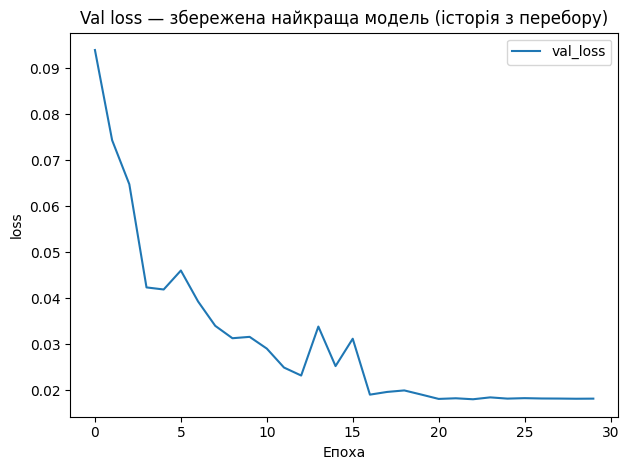

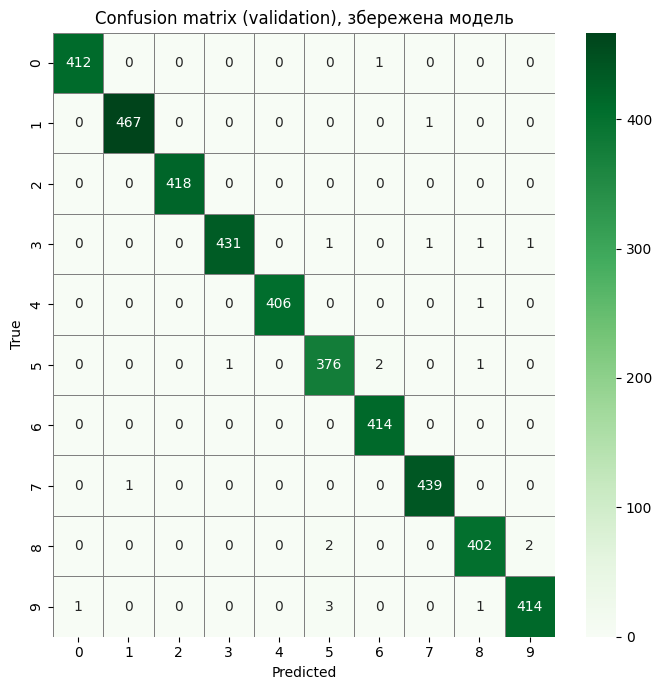

In [12]:
from pathlib import Path
import json

from sklearn.metrics import confusion_matrix
from keras.models import load_model

BEST_MODEL_PATH = Path("lab2_task1_best.keras")
BEST_HISTORY_PATH = Path("lab2_task1_best_history.json")
BEST_META_PATH = Path("lab2_task1_best_meta.json")

best_tab = results_df.sort_values("val_accuracy_max", ascending=False).iloc[0]
print("Топ-1 за таблицею results_df:")
print(best_tab.to_string())

if BEST_META_PATH.is_file():
    with open(BEST_META_PATH, encoding="utf-8") as fh:
        meta_saved = json.load(fh)
    print("\nКонфігурація збереженої моделі (остання, що оновила рекорд val_accuracy):")
    print(pd.Series(meta_saved).to_string())
else:
    meta_saved = None

if not BEST_MODEL_PATH.is_file():
    raise FileNotFoundError(
        "Немає збереженої моделі. Запусти комірку з перебором "
        f"(очікується {BEST_MODEL_PATH.resolve()})."
    )

model_best = load_model(BEST_MODEL_PATH)
print("\nМодель завантажена з диска (повторне навчання не виконується).")

if BEST_HISTORY_PATH.is_file():
    with open(BEST_HISTORY_PATH, encoding="utf-8") as fh:
        hist_best = json.load(fh)
    plt.plot(hist_best["val_loss"], label="val_loss")
    plt.xlabel("Епоха")
    plt.ylabel("loss")
    plt.legend()
    plt.title("Val loss — збережена найкраща модель (історія з перебору)")
    plt.tight_layout()
    plt.show()
else:
    print("Файл історії не знайдено — графік val_loss пропущено.")

Y_pred = model_best.predict(X_val, verbose=0)
Y_pred_classes = np.argmax(Y_pred, axis=1)
Y_true = np.argmax(Y_val, axis=1)
cm = confusion_matrix(Y_true, Y_pred_classes)

plt.figure(figsize=(7, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", linewidths=0.5, linecolor="gray")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion matrix (validation), збережена модель")
plt.tight_layout()
plt.show()
